In [1]:
# practice hierarchical clustering on mall dataset 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv('Mall_Customers.csv')
print(df.head())
# print(df.info())
df.columns

x = df[['Annual Income (k$)', 'Spending Score (1-100)']]



   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
x_scaled


##apply PCA (not necessary becuase in thisw we have given only 2 coplumn already)

# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# pca_scaled = pca.fit_transform(x_scaled)
# plt.scatter(x_scaled[:,0], x_scaled[:,1], cmap='viridis')
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")
# plt.title("Clusters (PCA View)")
# plt.show()




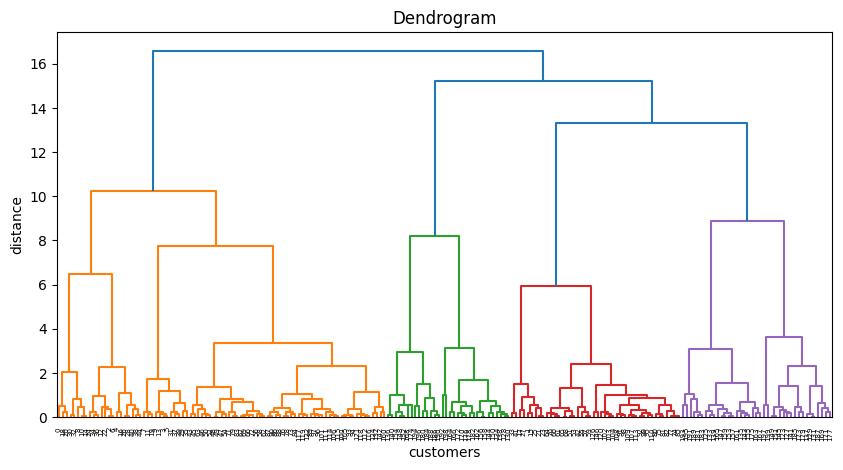

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage
z = linkage(x_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(z)
plt.title('Dendrogram')
plt.xlabel('customers')
plt.ylabel('distance')
plt.show()

In [17]:
##apply aglomerative clustering 
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(x_scaled)



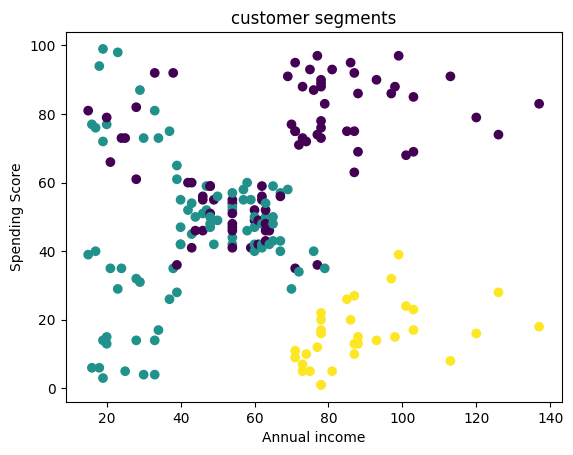

In [18]:
##vizualize cluster
plt.scatter(x.iloc[:,0], x.iloc[:,1], c=labels, cmap='viridis')
plt.xlabel("Annual income")
plt.ylabel("Spending Score")
plt.title("customer segments")
plt.show()


In [ ]:
# observation
# Cluster (Yellow – bottom right)
# High income + Low spending

# These customers earn a lot but spend less

# Interpretation:

# “Potential customers — they have money but are not spending much.”

# Business idea:

# Target them with offers/ads
# # ----------------------------------------------------------------

# Cluster (Purple – top right)
# High income + High spending

# Interpretation:

# “Premium / Target customers — high value customers.”

# Business idea:
# Focus retention
# VIP services
# ------------------------------------------------------------------

# Cluster (Green – left + middle)
# This cluster is mixed but mostly:

# Low/medium income + moderate spending

# Interpretation:
# “Average customers”

# Business idea:
# Regular marketing

